# Практика 5. Шкали вимірювання і частотний розподіл (варіант 3)

**Студент:** Стас Катренко, група ІТ-41  
**Місто:** Одеса  
**Дані:** середньомісячна кількість атмосферних опадів (мм)

## Мета
- Класифікувати змінні (місто, номер місяця, кількість опадів) за шкалою вимірювання.
- Побудувати варіаційний ряд та частотну таблицю (абсолутна, відносна, накопичена частота).
- Побудувати гістограми з різною кількістю інтервалів та оцінити оптимальну кількість за правилами √n та Стерджеса.
- Обчислити міри положення (середнє, медіана, мода) та квартилі.
- Відповісти на підсумкові питання.

**1**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

city_name = "Одеса"
months = np.arange(1, 13)
precip_vals = pd.Series([30, 28, 25, 28, 35, 45, 40, 35, 30, 28, 35, 33], name="Опади")

print(f"Обрано Варіант 3: {city_name}")
print("Початкові дані:", precip_vals.tolist())

Обрано Варіант 3: Одеса
Початкові дані: [30, 28, 25, 28, 35, 45, 40, 35, 30, 28, 35, 33]


In [3]:
variational_series = np.sort(precip_vals.values)
print(f"Варіаційний ряд опадів для м. {city_name}:")
print(variational_series)

counts, bin_edges = np.histogram(precip_vals, bins=4)

bins_labels = [f"[{round(bin_edges[i], 1)} - {round(bin_edges[i+1], 1)})" for i in range(len(bin_edges)-1)]
freq_abs = counts
freq_rel = (counts / len(precip_vals)) * 100
freq_cum = np.cumsum(counts)

freq_table = pd.DataFrame({
    "Інтервал опадів (мм)": bins_labels,
    "Абсолютна частота": freq_abs,
    "Відносна частота (%)": np.round(freq_rel, 1),
    "Накопичена частота": freq_cum
})

display(freq_table)

cum_3rd = freq_cum[2]
rel_cum_3rd = (cum_3rd / len(precip_vals)) * 100
print(f"\nЧастка місяців з опадами ≤ {round(bin_edges[3], 1)} мм (межа 3-го інтервалу): {rel_cum_3rd:.1f}% ({cum_3rd} з 12 місяців)")

Варіаційний ряд опадів для м. Одеса:
[25 28 28 28 30 30 33 35 35 35 40 45]


,Інтервал опадів (мм),Абсолютна частота,Відносна частота (%),Накопичена частота
0,[25.0 - 30.0),4,33.3,4
1,[30.0 - 35.0),3,25.0,7
2,[35.0 - 40.0),3,25.0,10
3,[40.0 - 45.0),2,16.7,12



Частка місяців з опадами ≤ 40.0 мм (межа 3-го інтервалу): 83.3% (10 з 12 місяців)


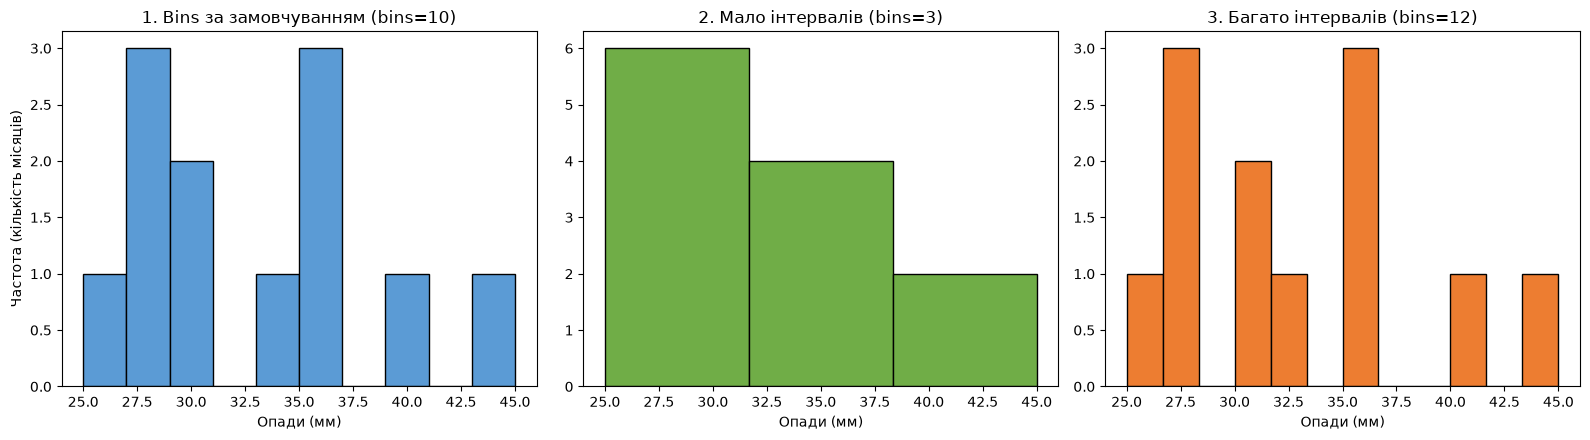

Орієнтовна кількість інтервалів за правилом √n: 3
Орієнтовна кількість інтервалів за правилом Стерджеса: 5


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(precip_vals, bins=10, edgecolor="black", color="#5B9BD5")
axes[0].set_title("1. Bins за замовчуванням (bins=10)")
axes[0].set_xlabel("Опади (мм)")
axes[0].set_ylabel("Частота (кількість місяців)")

axes[1].hist(precip_vals, bins=3, edgecolor="black", color="#70AD47")
axes[1].set_title("2. Мало інтервалів (bins=3)")
axes[1].set_xlabel("Опади (мм)")

axes[2].hist(precip_vals, bins=12, edgecolor="black", color="#ED7D31")
axes[2].set_title("3. Багато інтервалів (bins=12)")
axes[2].set_xlabel("Опади (мм)")

plt.tight_layout()
plt.show()

n = len(precip_vals) # n = 12
k_sqrt = int(np.round(np.sqrt(n)))
k_sturges = int(np.round(1 + 3.322 * np.log10(n)))

print(f"Орієнтовна кількість інтервалів за правилом √n: {k_sqrt}")
print(f"Орієнтовна кількість інтервалів за правилом Стерджеса: {k_sturges}")

In [5]:
mean_val = precip_vals.mean()
median_val = precip_vals.median()
modes = precip_vals.mode().tolist()

q1 = precip_vals.quantile(0.25)
q3 = precip_vals.quantile(0.75)

print(f"Середнє арифметичне: {mean_val:.2f} мм")
print(f"Медіана:             {median_val:.2f} мм")
print(f"Мода(и):             {modes} мм")
print(f"Перший квартиль (Q1): {q1:.2f} мм")
print(f"Третій квартиль (Q3): {q3:.2f} мм")

Середнє арифметичне: 32.67 мм
Медіана:             31.50 мм
Мода(и):             [28, 35] мм
Перший квартиль (Q1): 28.00 мм
Третій квартиль (Q3): 35.00 мм


## Підсумкові письмові відповіді на 4 питання практики

1. **Чому середнє арифметичне некоректне для номінальної змінної «місто», навіть після числового кодування?**
Числове кодування (наприклад, Київ = 1, Львів = 2, Одеса = 3) є абсолютно довільним умовним позначенням. Обчислення середнього значень $1$ і $3$ дасть $2$ («середнє між Києвом і Одесою — це Львів»), що не має жодного математичного чи реального змісту.
2. **Чому «номер місяця» є прикладом неоднозначної класифікації шкали?**
Тому що номери місяців (1–12) мають суворий порядок та приблизно однакові інтервали (близько 30 днів), що наближає їх до інтервальної шкали. Проте ця шкала **не має природного нуля** («0-й місяць» відсутній) і тривалість місяців є різною (28–31 день), через що її частіше класифікують як **порядкову**.
3. **Чому для «кількості опадів» потрібна гістограма, а не стовпчикова діаграма?**
Опади — це неперервна числова змінна. Стовпчикова діаграма будується за окремими дискретними значеннями. Оскільки більшість із 12 значень опадів є унікальними, стовпчикова діаграма покаже 12 однакових стовпчиків висотою 1, що не передає форма розподілу. Гістограма ж групує неперервні дані в **інтервали (bins)**, демонструючи щільність розподілу.
4. **Що змістовно означає накопичена частота на межі 3-го інтервалу?**
Для Одеси межа 3-го інтервалу дорівнює $40 \text{ мм}$, а накопичена частота становить $10$ ($83.3\%$). Це означає, що **протягом 10 місяців року (або $83.3\%$ всього часу) рівень опадів в Одесі не перевищував $40 \text{ мм}$ на місяць**.